In [178]:
import mne
import pyxdf
import matplotlib.pyplot as plt
import numpy as np

import re

In [179]:
filename = "/Users/ojasprabhune/Documents/research/NORA/recordings/lsl/sub-P001/ses-S001/eeg/sub-P001_ses-S001_task-Default_run-001_eeg.xdf"
streams, header = pyxdf.load_xdf(filename)

EMOTIV_CHANNELS = [
    "AF3", "F7", "F3", "FC5", "T7", "P7", "O1",
    "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"
]

In [180]:
eeg_stream = streams[1]
marker_stream = streams[0]

eeg_ts = eeg_stream["time_stamps"]
t_start = eeg_ts[0]
time_axis = eeg_ts - t_start  # Align time to start at 0
eeg_signal = eeg_stream["time_series"]  # Shape: (samples, channels)

print(eeg_ts.shape)
# print(eeg_signal)

num_available_channels = eeg_signal.shape[1]

(326644,)


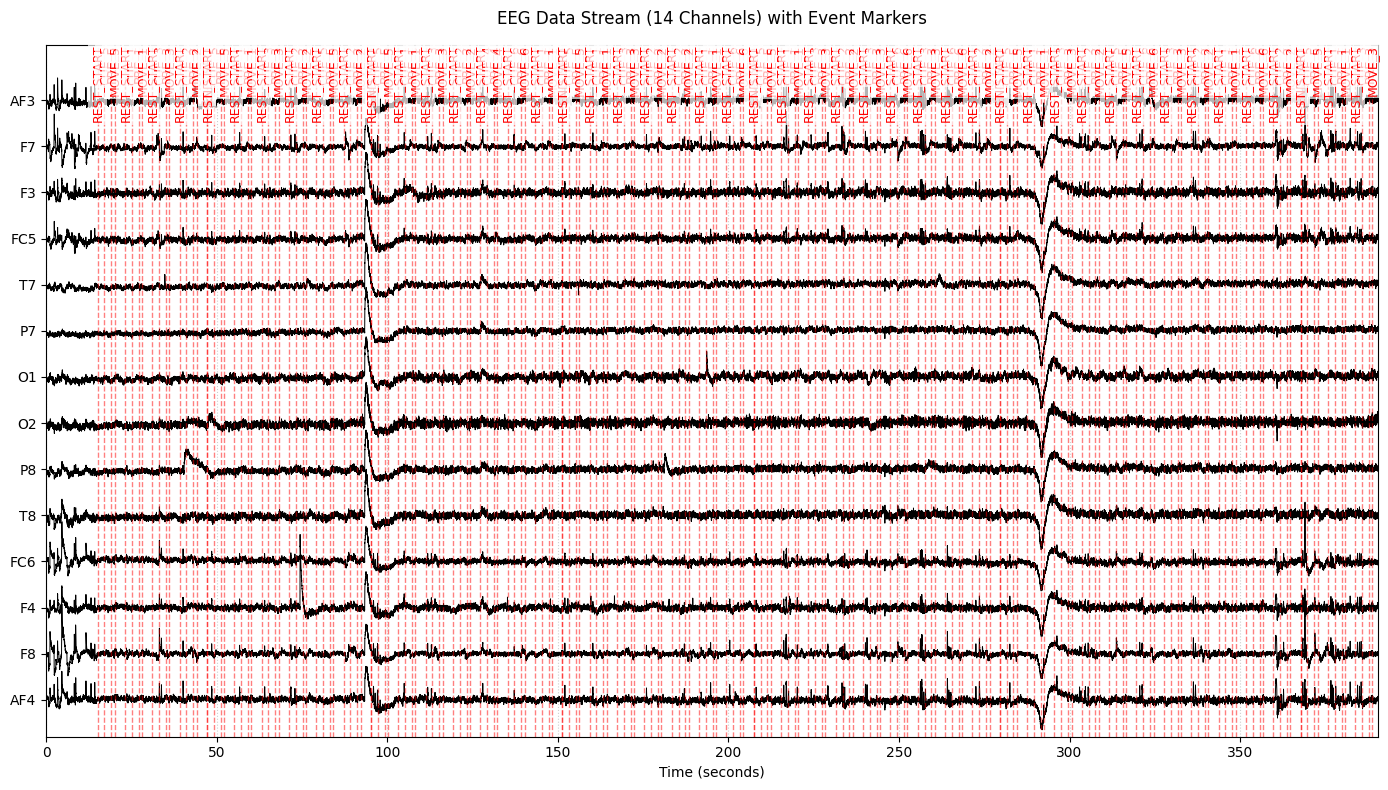

In [181]:
labels_in_file = [
    ch["label"][0]
    for ch in eeg_stream["info"]["desc"][0]["channels"][0]["channel"]
]
indices_to_plot = [
    labels_in_file.index(ch) for ch in EMOTIV_CHANNELS if ch in labels_in_file
]
channel_labels = [labels_in_file[i] for i in indices_to_plot]

# Extract raw data for chosen channels
eeg_plot_data = eeg_signal[:, indices_to_plot].copy()

MAX_TIMESTEPS = 50000  # Set to None to plot everything

if MAX_TIMESTEPS is not None:
    eeg_plot_data = eeg_plot_data[:MAX_TIMESTEPS]
    time_axis = time_axis[:MAX_TIMESTEPS]

# --- 2. Z-Score Normalization (Per Channel) ---
for i in range(eeg_plot_data.shape[1]):
    mean = np.nanmean(eeg_plot_data[:, i])
    std = np.nanstd(eeg_plot_data[:, i])
    if std > 0:
        eeg_plot_data[:, i] = (eeg_plot_data[:, i] - mean) / std

# Increased spacing offset prevents overlap during large artifact spikes
spacing_offset = 12.0 

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(14, 8))

for idx in range(len(indices_to_plot)):
    offset = idx * spacing_offset
    ax.plot(
        time_axis,
        eeg_plot_data[:, idx] - offset,
        color="black",
        linewidth=0.7,
    )

# --- 4. Y-Axis Ticks & Label Mapping ---
y_tick_positions = [-i * spacing_offset for i in range(len(indices_to_plot))]
ax.set_yticks(y_tick_positions)
ax.set_yticklabels(channel_labels)

# Set Y-limits to tightly fit the channels, giving top margin for markers
ax.set_ylim(min(y_tick_positions) - (spacing_offset * 0.8), spacing_offset * 1.2)

# --- 5. Event Markers ---
if marker_stream is not None:
    marker_ts = marker_stream["time_stamps"] - t_start
    marker_vals = marker_stream["time_series"]

    # Keep only markers within plotted time window
    mask = (marker_ts >= time_axis[0]) & (marker_ts <= time_axis[-1])
    marker_ts = marker_ts[mask]
    marker_vals = np.array(marker_vals, dtype=object)[mask]

    _, y_max = ax.get_ylim()

    for ts, marker in zip(marker_ts, marker_vals):
        label_text = (
            marker[0] if isinstance(marker, (list, np.ndarray)) else str(marker)
        )

        # Draw vertical line
        ax.axvline(x=ts, color="red", linestyle="--", alpha=0.5, linewidth=1)

        # Anchor text inside the plot, hanging down from the top edge
        ax.text(
            ts,
            y_max, 
            label_text,
            color="red",
            rotation=90,
            fontsize=9,
            verticalalignment="top", 
            horizontalalignment="center",
            bbox=dict(
                facecolor="white", alpha=0.7, edgecolor="none", pad=2
            ),
        )

# --- 6. Formatting & Display ---
ax.set_xlabel("Time (seconds)")
ax.set_title("EEG Data Stream (14 Channels) with Event Markers", pad=15)
ax.grid(axis="x", linestyle=":", alpha=0.6)
ax.set_xlim(time_axis[0], time_axis[-1])

plt.tight_layout()
plt.show()

In [182]:
# get EEG data (samples, channels) -> transpose to (channels, samples)
data = eeg_stream["time_series"].T.astype(float)

# get channel labels from the XDF metadata
labels = [
    ch["label"][0]
    for ch in eeg_stream["info"]["desc"][0]["channels"][0]["channel"]
]

indices = [labels.index(ch) for ch in EMOTIV_CHANNELS]

# keep only those channels
data = eeg_stream["time_series"].T.astype(float)
data = data[indices]

In [183]:
sfreq = float(eeg_stream["info"]["nominal_srate"][0])

info = mne.create_info(
    ch_names=EMOTIV_CHANNELS,
    sfreq=sfreq,
    ch_types="eeg",
)

raw = mne.io.RawArray(data, info)

Creating RawArray with float64 data, n_channels=14, n_times=326644
    Range : 0 ... 326643 =      0.000 ...  2551.898 secs
Ready.


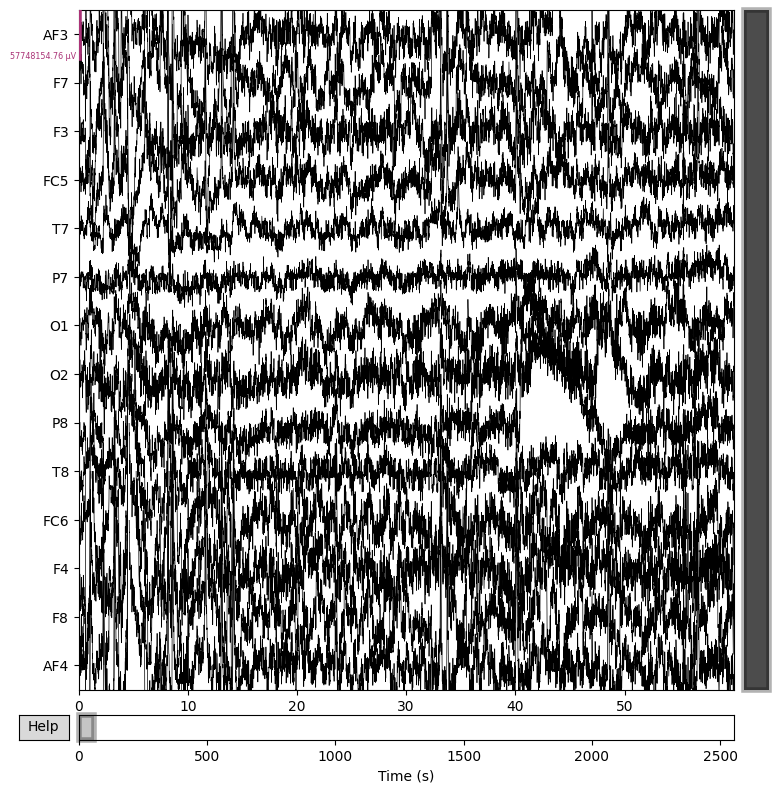

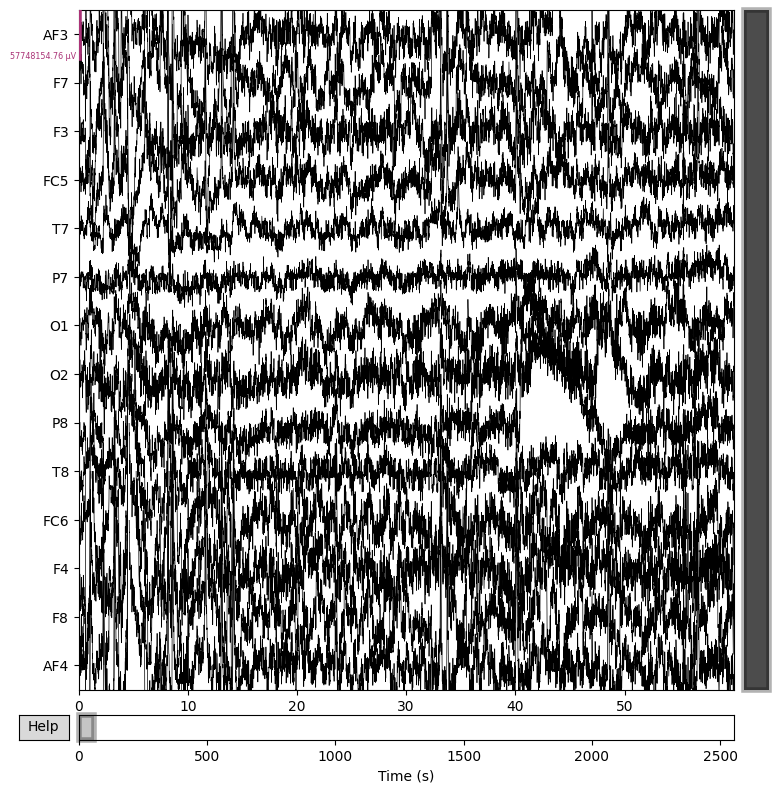

In [184]:
raw.plot(
    duration=60,
    scalings="auto",
    title="EEG Recording"
)

In [185]:
marker_times = marker_stream["time_stamps"]
marker_labels = marker_stream["time_series"]
sfreq = raw.info["sfreq"]
eeg_start = eeg_stream["time_stamps"][0]

event_dict = {
    "REST_START": 1,
    "CUE": 2,
    "PRE": 3,
    "MOVE": 4,
    "END_SEQ": 5,
}

events = []

for t, marker in zip(marker_stream["time_stamps"], marker_stream["time_series"]):
    # marker is like ['MOVE_5']
    marker = marker[0]

    # remove the trailing "_5", "_2", etc.
    event_name = re.sub(r'_?\d+', '', marker)

    sample = int(round((t - eeg_start) * sfreq))
    events.append([sample, 0, event_dict[event_name]])

events = np.array(events, dtype=int)

In [206]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.5,
    tmax=2.5,
    preload=True,
    event_repeated="drop",
    verbose=False
)

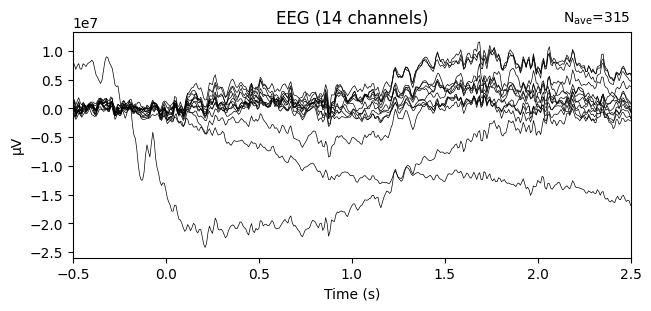

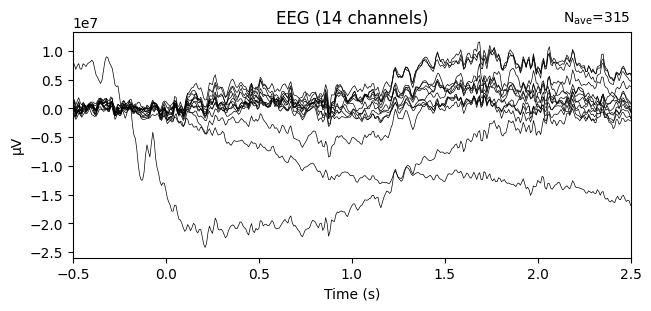

In [207]:
epochs["MOVE"].average().plot()